In [77]:
import pandas as pd
import numpy as np
import xarray as xr

In [4]:
dates = pd.read_csv("/g/data/ng72/ab4502/hot-cloudy/data/event_dates_csi0p5_tmax90.csv")[["time","region"]]


In [29]:
swt = xr.open_dataset("/g/data/ng72/ab4502/Australian-synoptic-weather-types/SWT_fields/SWT_climatology.nc")
swt["time"] = swt["time"].dt.date
types = swt.SWTs.values

In [56]:
r="GMEL"



array(['GMEL', 'GSYD', 'GADE', 'GBRI'], dtype=object)

In [68]:
import matplotlib.pyplot as plt

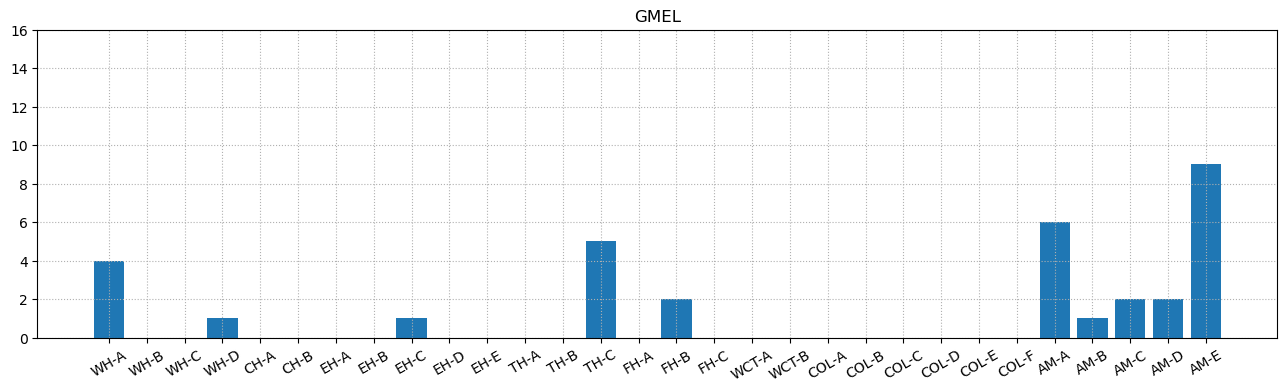

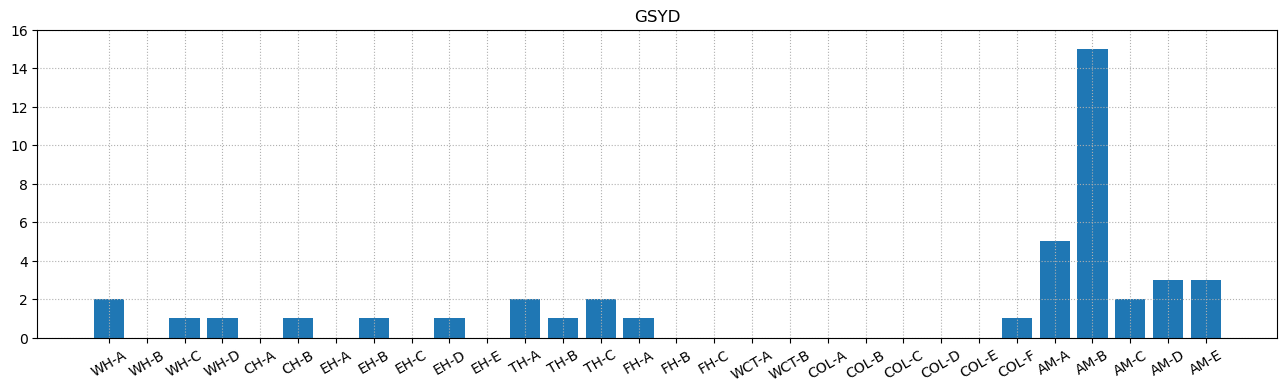

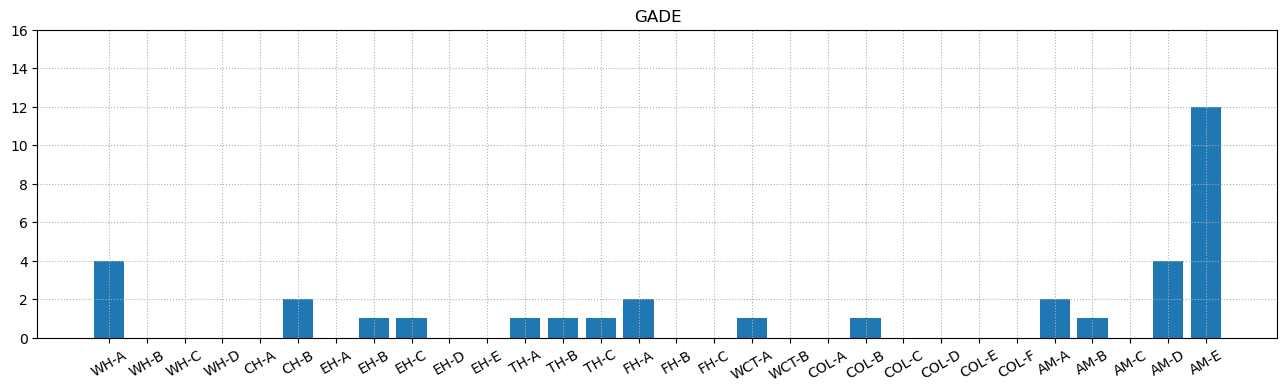

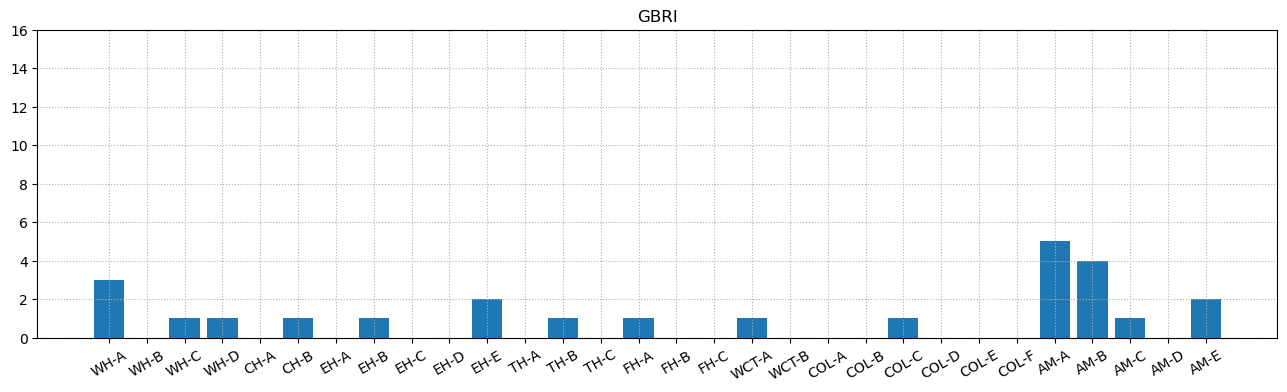

In [92]:
for r in dates.region.unique():
    swt_r = swt.sel(time=pd.to_datetime(dates[dates["region"]==r].time.values).date).assigned_SWT.to_dataframe()
    counts = []
    for t in types:
        counts.append((swt_r == t).sum().values[0])
    counts_r = pd.DataFrame({"count":counts},index=types)
    
    plt.figure(figsize=[16,4])
    plt.bar(x=types,height=counts_r.values.squeeze())
    plt.gca().tick_params(axis="x",rotation=30)

    plt.gca().grid(ls=":")
    
    plt.title(r)

    plt.ylim([0,16])